# **Quatile Regression based on Copula Modeling: Non-parametric (Kernel Smoothing) modeling**

In [1]:
!pip install openturns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.6 MB/s eta 0:00:00


Access to google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing libraries

In [3]:
import os
import warnings
#from __future__ import print_function
import time
#from numba import jit
import openturns as ot
import pandas as pd
import  numpy as np
import scipy.stats
#from scipy.misc import comb
#from pynverse import inversefunc
#import pyvine as pv
import tkinter as tk
from tkinter.filedialog import askopenfilename
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from openturns.viewer import View
import pylab as pl
import openturns.viewer as otv
import math as m

Auxiliary Functions' Definitions

In [4]:
def rmse(obs,prd):
    return np.sqrt(np.mean((obs-prd)**2))

def scatterplot2D(x,y,pearson, spearman, kendall, xmin, xmax, ymin, ymax,  xlab, ylab, title, histbins=10):


    from matplotlib.ticker import NullFormatter
    from matplotlib.ticker import NullLocator
#    from mpl_toolkits.axes_grid1.anchored_artists import AnchoredText
    from matplotlib.offsetbox import AnchoredText

    plt.style.use('ggplot')
#    histbins=10
#    fig = plt.figure()
#    fig.suptitle(title, fontsize=12)

    nullfmt   = NullFormatter()         # no labels
    nullloc   = NullLocator()         # no labels

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    bottom_h = left_h = left+width+0.02
    height_h=0.2

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, height_h]
    rect_histy = [left_h, bottom, height_h, height]
    rect_histxy = [left_h, bottom_h, height_h, height_h]

    # start with a rectangular Figure
    fig = plt.figure(figsize=(8,8))
    fig.suptitle(title, fontsize=12)

    axScatter = plt.axes(rect_scatter)
    axHistx = plt.axes(rect_histx)
    axHisty = plt.axes(rect_histy)
    axHistxy = plt.axes(rect_histxy)

    # no labels
    axHistx.xaxis.set_major_formatter( nullfmt)
    axHisty.yaxis.set_major_formatter( nullfmt)
    axHistxy.xaxis.set_major_formatter( nullfmt)
    axHistxy.yaxis.set_major_formatter( nullfmt)
    axHistxy.xaxis.set_major_locator( nullloc )
    axHistxy.yaxis.set_major_locator( nullloc )

    # the scatter plot:
    axScatter.scatter(x, y
#                      ,c=pointcolor, marker=pointsymbol
                      )

    # now determine nice limits by hand:
#    binwidth = 0.25
#    xymax = np.max( [np.max(np.fabs(x)), np.max(np.fabs(y))] )
#    lim = ( int(xymax/binwidth) + 1) * binwidth

    axScatter.set_xlim( (xmin, xmax) )
    axScatter.set_ylim( (ymin, ymax) )

#    bins = np.arange(-lim, lim + binwidth, binwidth)
    axHistx.hist(x, bins=histbins)
    axHisty.hist(y, bins=histbins, orientation='horizontal')

    axHistx.set_xlim( axScatter.get_xlim() )
    axHisty.set_ylim( axScatter.get_ylim() )


#    fig, ax = plt.subplots()
#    ax.scatter(delta1[:-1], delta1[1:], c=close, s=volume, alpha=0.5)

    axScatter.set_xlabel(xlab, fontsize=16)
    axScatter.set_ylabel(ylab, fontsize=16)
#    axScatter.set_title(sp_title)

    axScatter.grid(True)


    plt.text(left_h-width, bottom_h, 'Corr. coefficients')
    plt.text(left_h-width, bottom_h-0.2, 'Pearson = '+pearson[0:7], fontsize=12)
    plt.text(left_h-width, bottom_h-0.4, 'Spearman = '+spearman[0:7], fontsize=12)
    plt.text(left_h-width, bottom_h-0.6, 'Kendall = '+kendall[0:7], fontsize=12)

#    rect = plt.Rectangle((left_h, bottom_h), height_h, height_h, facecolor="#aaaaaa")

    axScatter.legend('lines',title=title, loc='upper center', shadow=True, fontsize='x-large')

    # Put a nicer background color on the legend.
#    legend.get_frame().set_facecolor('#00FFCC')

#    if self.linear_regression:
#        xfit = array( [amin(x), amax(x) ] )
#        plot(xfit, line_fit(xfit,a0,a1), 'r-', lw=2)


    plt.show()

def scatter_hist(x, y, ax, ax_histx, ax_histy, xlab, ylab):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=xlab)
    ax_histy.tick_params(axis="y", labelleft=ylab)

    # the scatter plot:
    ax.scatter(x, y)

    # now determine nice limits by hand:
    binwidth = 0.25
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth

    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, bins=bins)
    ax_histy.hist(y, bins=bins, orientation='horizontal')

#    plt.text(left_h-width, bottom_h, 'Corr. coefficients')
#    plt.text(left_h-width, bottom_h-0.2, 'Pearson = '+pearson[0:7], fontsize=12)
#    plt.text(left_h-width, bottom_h-0.4, 'Spearman = '+spearman[0:7], fontsize=12)
#    plt.text(left_h-width, bottom_h-0.6, 'Kendall = '+kendall[0:7], fontsize=12)

def XYplot(x,y, xmin, xmax,  ymin, ymax, xlab, ylab, title, symbol='.', color='red'):
    plt.style.use('ggplot')

    fig = plt.figure()
    fig.suptitle(title, fontsize=12)
    plt.scatter(x,y,marker=symbol,color=color)
    plt.xlim(xmin,xmax)
    plt.ylim(ymin,ymax)
#    plt.title(' Ip vs Phit pseudo observations')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.grid(True)
    plt.show()

def plot3d(x,y,z,label=None, xlabel=None, ylabel=None, color='b',show=False):
    assert len(x)==len(y)==len(z), "Cant 3dplot. At least one dimension \
    differs in shape x{}-y{}-z{}".format(len(x),len(y),len(z))
    fig = pl.figure()
    ax = fig.Axes3D()
    ax.scatter(x,y,z,c=color)
    if label != None:
        ax.text2D(0.05, 0.95, label, transform=ax.transAxes)
        ax.set_xlabel('X: {}'.format(xlabel))
        ax.set_ylabel('Y: {}'.format(ylabel))
        ax.set_zlabel('Copula family: {}'.format(label))
    if show:
        try:
            plt.show()
        except:
            print ("could not plot {}".format(label))
            return
    return [fig,ax]

def multipage(filename, figs=None, dpi=200):

    pp = PdfPages(filename)
    if figs is None:
        figs = [plt.figure(n) for n in plt.get_fignums()]
    for fig in figs:
        fig.savefig(pp, format='pdf')
    pp.close()


Importing Data

In [5]:
# Measure the time the program takes
start_time = time.time()

# Input file name (.csv)
filename='DTCO_DTSM'

Depth_min=860.7552
Depth_max=1812.1884

dir = os.getcwd()
dir

## read the data and do rank transformation
#data = pd.read_csv(filename_csv,index_col = 0)
sample = ot.Sample.ImportFromCSVFile(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Data/'+ filename +'.csv', ',')
sample.setName("sample")
#sample.setDescription(['Ip', 'PhiT'])
#print(sample)
#type(sample)

# get Dimension
n_var = sample.getDimension()

# get size
sample_size=sample.getSize()

# get name
name_var1 =  sample.getDescription()[0]
name_var2 =  sample.getDescription()[1]
# print(sample[:5])
label_var1=name_var1
label_var2=name_var2
var1=sample[:,0]
var1.setName(label_var1)
var2=sample[:,1]
var2.setName(label_var2)

### Univariate statistics

In [6]:
print("--------------------------------------------------")
print('Summary of Univariate Statistics')
print("--------------------------------------------------")
print('Size=',sample.getSize())
print('Name=',sample.getDescription())
print('Minimum=',sample.getMin())
print('1st quartile=',sample.computeQuantilePerComponent(0.25))
print('Mean=',sample.computeMean())
print('Median=',sample.computeMedian())
print('3rd quartile=',sample.computeQuantilePerComponent(0.75))
print('Maximum=',sample.getMax())
print('Range=',sample.computeRange())
print('Variance=',sample.computeVariance())
print('Standard Deviation=',sample.computeStandardDeviation())
print('Skewness=',sample.computeSkewness())
print('Kurtosis=',sample.computeKurtosis())

--------------------------------------------------
Summary of Univariate Statistics
--------------------------------------------------
Size= 6244
Name= [DTCO_o,DTSM_o]
Minimum= [55.1563,102.26]
1st quartile= [78.9463,152.989]
Mean= [86.7315,175.294]
Median= [87.0729,172.247]
3rd quartile= [95.7942,199.933]
Maximum= [122.669,295.612]
Range= [67.513,193.352]
Variance= [108.117,825.404]
Standard Deviation= [10.3979,28.7298]
Skewness= [-0.278645,0.0114791]
Kurtosis= [2.23375,2.24028]


### Bivariate statistics

In [7]:
print("--------------------------------------------------")
print('Summary of Bivariate Statistics')
print("--------------------------------------------------")
print('Covariance=',sample.computeCovariance())
print('Standard Deviation=',sample.computeStandardDeviation())
print('Pearson correlation matrix=',sample.computePearsonCorrelation())
print('Kendall correlation matrix=',sample.computeKendallTau())
print('Spearman  correlation matrix=',sample.computeSpearmanCorrelation())
print("--------------------------------------------------")

--------------------------------------------------
Summary of Bivariate Statistics
--------------------------------------------------
Covariance= [[ 108.117 291.695 ]
 [ 291.695 825.404 ]]
Standard Deviation= [10.3979,28.7298]
Pearson correlation matrix= [[ 1        0.976447 ]
 [ 0.976447 1        ]]
Kendall correlation matrix= [[ 1        0.888136 ]
 [ 0.888136 1        ]]
Spearman  correlation matrix= [[ 1        0.981312 ]
 [ 0.981312 1        ]]
--------------------------------------------------


### Create pairs drawable

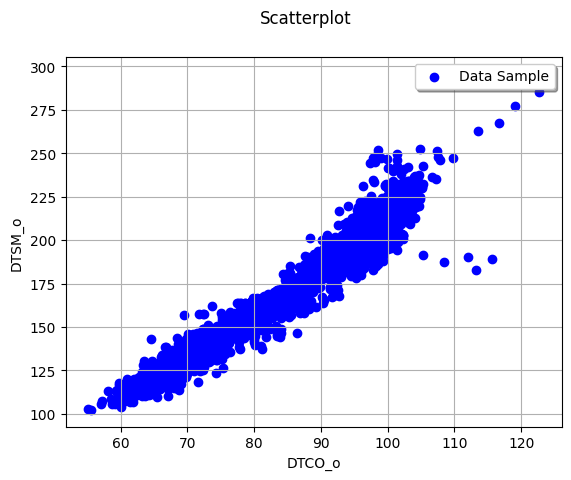

In [8]:
cloud_DS = ot.Cloud(sample, 'blue', 'fcircle', 'Data Sample')
figure_DS = ot.Graph("Scatterplot", label_var1, label_var2, True, 'topright')
figure_DS.add(cloud_DS)
view = otv.View(figure_DS)
#plt.show()
view.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/'+ filename +"_scatterplot.png", dpi=200)

## NON-PARAMETRIC COPULA MODELING WITH KERNEL SMOOTHING

### Estimate Kernel Smoothing marginals

In [9]:
kernel_distribution = ot.Epanechnikov()
# Estimate Kernel Smoothing marginals
kernel = ot.KernelSmoothing(kernel_distribution)
estimated_kernel_var1 = kernel.build(var1)

### Plot sample vs kernel smoothing distribution (CDF) for var1

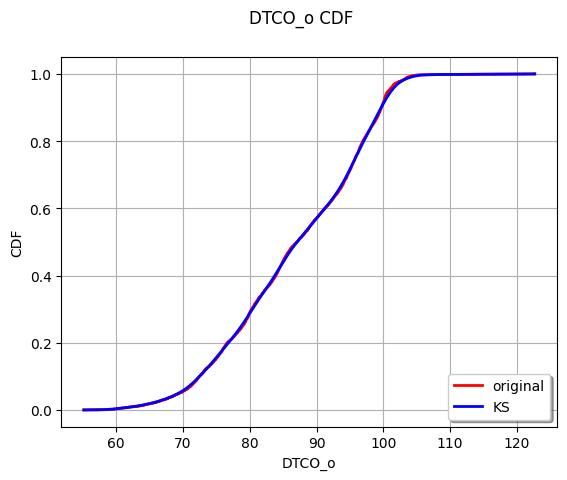

In [11]:
graph = ot.Graph()
graph.setTitle('Kernel smoothing vs original')
xmin = var1.getMin()[0] # - 1.0
xmax = var1.getMax()[0] # + 1.0
graph = ot.UserDefined(var1).drawCDF(xmin, xmax)
#graph.add(distribution.drawCDF())
kernel_plot = estimated_kernel_var1.drawCDF(xmin, xmax).getDrawable(0)
kernel_plot.setColor('blue')
graph.add(kernel_plot)
graph.setLegends(['original', 'KS'])
graph.setLegendPosition('bottomright')
view = otv.View(graph)
view.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Non-parametric kernel smoothing vs empirical CDF_' +label_var1+".png", dpi=200)

### Plot sample vs kernel smoothing distribution (PDF) for var1

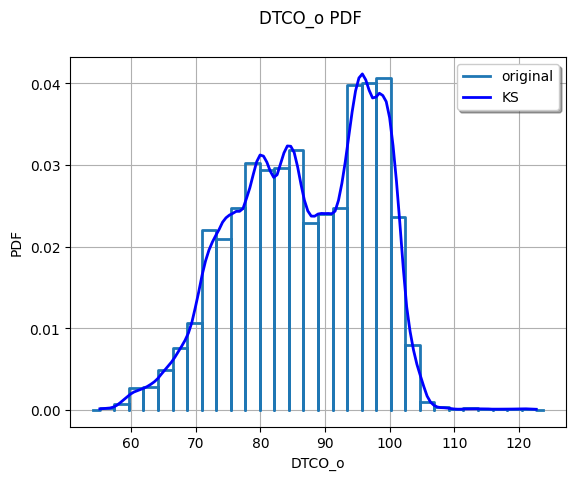

In [12]:
graph1 = ot.Graph()
graph1.setTitle('Kernel smoothing vs original')
graph1 = ot.HistogramFactory().build(var1).drawPDF()
#graph1.add(fit_Normal_distribution_var1.drawPDF())
xmin = var1.getMin()[0] # - 1.0
xmax = var1.getMax()[0] # + 1.0
kernel_plot = estimated_kernel_var1.drawPDF(xmin, xmax).getDrawable(0)
kernel_plot.setColor('blue')
graph1.add(kernel_plot)
graph1.setLegends(['original', 'KS'])
graph1.setLegendPosition('topright')
view = otv.View(graph1)
view.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Non-parametric kernel smoothing vs empirical PDF_' +label_var1+".png", dpi=200)

### Plot sample vs kernel smoothing distribution (CDF) for var2

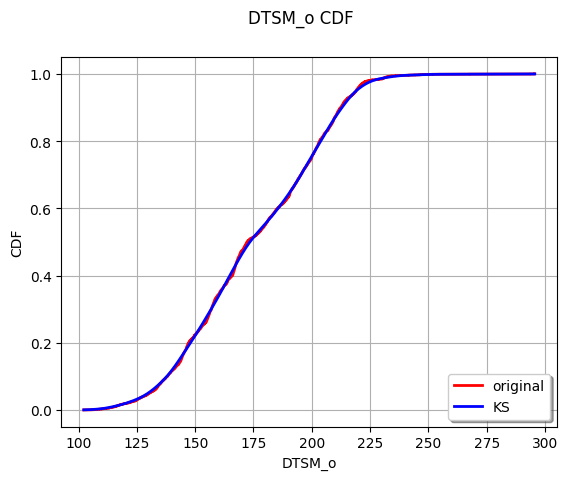

In [13]:
kernel = ot.KernelSmoothing(kernel_distribution)
estimated_kernel_var2 = kernel.build(var2)
# Plot sample vs kernel smoothing (CDF)
graph3 = ot.Graph()
graph3.setTitle('Kernel smoothing vs original')
xmin = var2.getMin()[0] #- 1.0
xmax = var2.getMax()[0] #+ 1.0
graph3 = ot.UserDefined(var2).drawCDF(xmin, xmax)
#graph3.add(distribution.drawCDF())
kernel_plot = estimated_kernel_var2.drawCDF(xmin, xmax).getDrawable(0)
kernel_plot.setColor('blue')
graph3.add(kernel_plot)
graph3.setLegends(['original', 'KS'])
graph3.setLegendPosition('bottomright')
view = otv.View(graph3)
view.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Non-parametric kernel smoothing vs empirical CDF_' +label_var2+".png", dpi=200)

### Plot sample vs kernel smoothing distribution (PDF) for var2

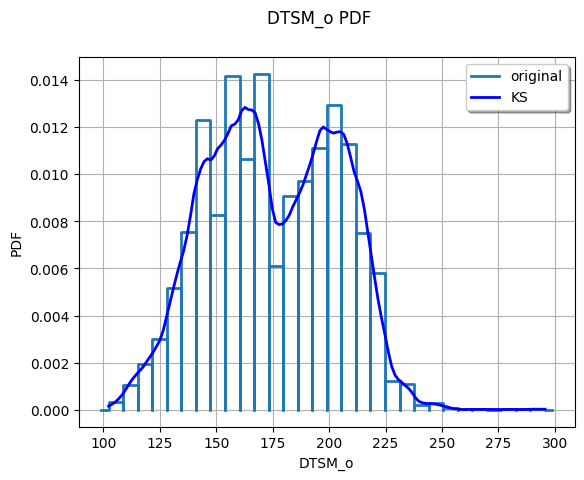

In [14]:
graph2 = ot.Graph()
graph2.setTitle('Kernel smoothing vs original')
graph2 = ot.HistogramFactory().build(var2).drawPDF()
xmin = var2.getMin()[0] # - 1.0
xmax = var2.getMax()[0] # + 1.0
kernel_plot = estimated_kernel_var2.drawPDF(xmin, xmax).getDrawable(0)
kernel_plot.setColor('blue')
graph2.add(kernel_plot)
graph2.setLegends(['original', 'KS'])
graph2.setLegendPosition('topright')
view = otv.View(graph2)
view.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Non-parametric kernel smoothing vs empirical PDF_' +label_var2+".png", dpi=200)

### Find connected components of a graph defined from its adjacency matrix

In [ ]:
def find_neighbours(head, covariance, to_visit, visited):
    N = covariance.getDimension()
    visited[head] = 1
    to_visit.remove(head)
    current_component = [head]
    for i in to_visit:
        # If i is connected to head and has not yet been visited
        if covariance[head, i] > 0:
            # Add i to the current component
            component = find_neighbours(i, covariance, to_visit, visited)
            current_component += component
    return current_component

def connected_components(covariance):
    N = covariance.getDimension()
    to_visit = list(range(N))
    visited = [0] * N
    all_components = []
    for head in range(N):
        if visited[head] == 0:
            component = find_neighbours(head, covariance, to_visit, visited)
            all_components.append(sorted(component))
    return all_components

### Fit a non parametric copula using KernelSmoothing

In [23]:
KernelSmoothing_copula_distribution = ot.KernelSmoothing(kernel_distribution).build(sample).getCopula()


### Build joint distribution from marginal distributions and dependency structure

In [18]:
KernelSmoothing_bivariate_distribution=ot.ComposedDistribution([estimated_kernel_var1,estimated_kernel_var2],KernelSmoothing_copula_distribution)

### Plot bivariate distribution (CDF)

In [22]:
#KernelSmoothing_copula_distribution.drawCDF()

### Plot bivariate distribution (PDF)

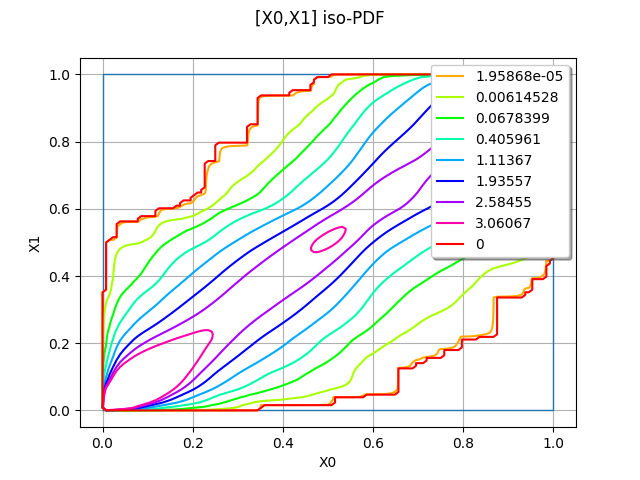

In [20]:
KernelSmoothing_copula_distribution.drawPDF()

### Simulations from fitted parametric multivariate distribution

In [24]:
simulation_vector=ot.RandomVector(KernelSmoothing_bivariate_distribution)
simulation_size=sample_size
simulation=simulation_vector.getSample(simulation_size)

label_var1_sim=label_var1+'_sim'
label_var2_sim=label_var2+'_sim'
simulation.setDescription([label_var1_sim,label_var2_sim])

### Summary of Univariate Statistics: Kernel Smoothing copula

In [25]:
var1_sim=simulation[:,0]
var1_sim.setName(label_var1_sim)

var2_sim=simulation[:,1]
var2_sim.setName(label_var2_sim)

print('Size=',simulation.getSize())
print('Name=',simulation.getDescription())
print('Minimum=',simulation.getMin())
print('1st quartile=',simulation.computeQuantilePerComponent(0.25))
print('Mean=',simulation.computeMean())
print('Median=',simulation.computeMedian())
print('3rd quartile=',simulation.computeQuantilePerComponent(0.75))
print('Maximum=',simulation.getMax())
print('Range=',simulation.computeRange())
print('Variance=',simulation.computeVariance())
print('Standard Deviation=',simulation.computeStandardDeviation())
print('Skewness=',simulation.computeSkewness())
print('Kurtosis=',simulation.computeKurtosis())

Size= 6244
Name= [DTCO_o_sim,DTSM_o_sim]
Minimum= [53.2309,96.8271]
1st quartile= [78.765,152.368]
Mean= [86.6778,175.122]
Median= [87.0941,172.875]
3rd quartile= [95.8489,199.638]
Maximum= [124.855,298.353]
Range= [71.6243,201.526]
Variance= [110.182,842.053]
Standard Deviation= [10.4968,29.0182]
Skewness= [-0.244128,0.0345501]
Kurtosis= [2.26882,2.34028]


### Summary of Bivariate Statistics

In [26]:
print('Covariance=',simulation.computeCovariance())
print('Standard Deviation=',simulation.computeStandardDeviation())
print('Pearson correlation matrix=',simulation.computePearsonCorrelation())
print('Kendall correlation matrix=',simulation.computeKendallTau())
print('Spearman  correlation matrix=',simulation.computeSpearmanCorrelation())
print("--------------------------------------------------")

Covariance= [[ 110.182 276.178 ]
 [ 276.178 842.053 ]]
Standard Deviation= [10.4968,29.0182]
Pearson correlation matrix= [[ 1      0.9067 ]
 [ 0.9067 1      ]]
Kendall correlation matrix= [[ 1        0.724994 ]
 [ 0.724994 1        ]]
Spearman  correlation matrix= [[ 1        0.908174 ]
 [ 0.908174 1        ]]
--------------------------------------------------


### Create a Pairs drawable

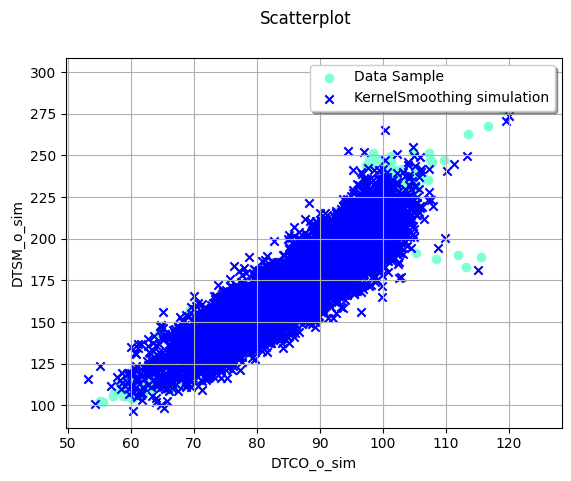

In [27]:
# PointStyles() [bullet,circle,diamond,dot,fcircle,fdiamond,fsquare,ftriangleup,none,plus,square,star,times,triangledown,triangleup]
cloud_DS = ot.Cloud(sample, 'aquamarine1', 'fcircle', 'Data Sample')
cloud_KS = ot.Cloud(simulation, 'blue', 'times', 'KernelSmoothing simulation')
figure_KS = ot.Graph("Scatterplot", label_var1_sim, label_var2_sim, True, 'topright')
figure_KS.add(cloud_DS)
figure_KS.add(cloud_KS)
view = otv.View(figure_KS)
view.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Non-parametric_Kernel_Smoothing_copula_simulation_'+ filename +'_scatterplot.png', dpi=200)

### Cloud in the rank space

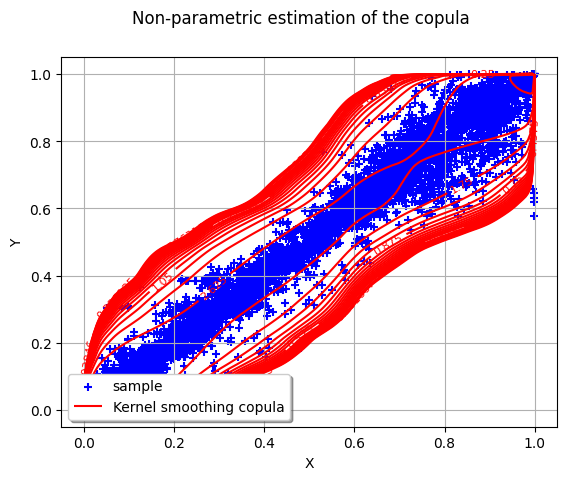

In [28]:
ranksTransf = ot.MarginalTransformationEvaluation([estimated_kernel_var1,estimated_kernel_var2], ot.MarginalTransformationEvaluation.FROM)
rankSample = ranksTransf(sample)
rankCloud = ot.Cloud(rankSample, 'blue', 'plus', 'sample')
# Graph with rank sample and estimated copula
myGraph_KS = ot.Graph('Non-parametric estimation of the copula', 'X', 'Y', True, 'topleft')
myGraph_KS.setLegendPosition('bottomleft')
myGraph_KS.add(rankCloud)
# Then draw the iso-curves of the estimated copula
minPoint = [0.0]*2
maxPoint = [1.0]*2
pointNumber = [201]*2
graphCop = KernelSmoothing_copula_distribution.drawPDF(minPoint, maxPoint, pointNumber)
contour_estCop = graphCop.getDrawable(0)
# Erase the labels of the iso-curves
contour_estCop.setDrawLabels(False)
# Change the levels of the iso-curves
nlev = 21
levels = ot.Point(nlev)
for i in range(nlev):
    levels[i] = 0.25 * nlev / (nlev - i)
contour_estCop.setLevels(levels)
# Change the legend of the curves
contour_estCop.setLegend('Kernel smoothing copula')
# Change the color of the iso-curves
contour_estCop.setColor('red')
contour_estCop.setDrawLabels(True)
# Add the iso-curves graph into the cloud one
myGraph_KS.add(contour_estCop)
view = otv.View(myGraph_KS)
view.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Non-parametric_Kernel_Smoothing_copula_'+ filename +'_scatterplot.png', dpi=200)

### Non-parametric Kernel Smoothing copula modeling

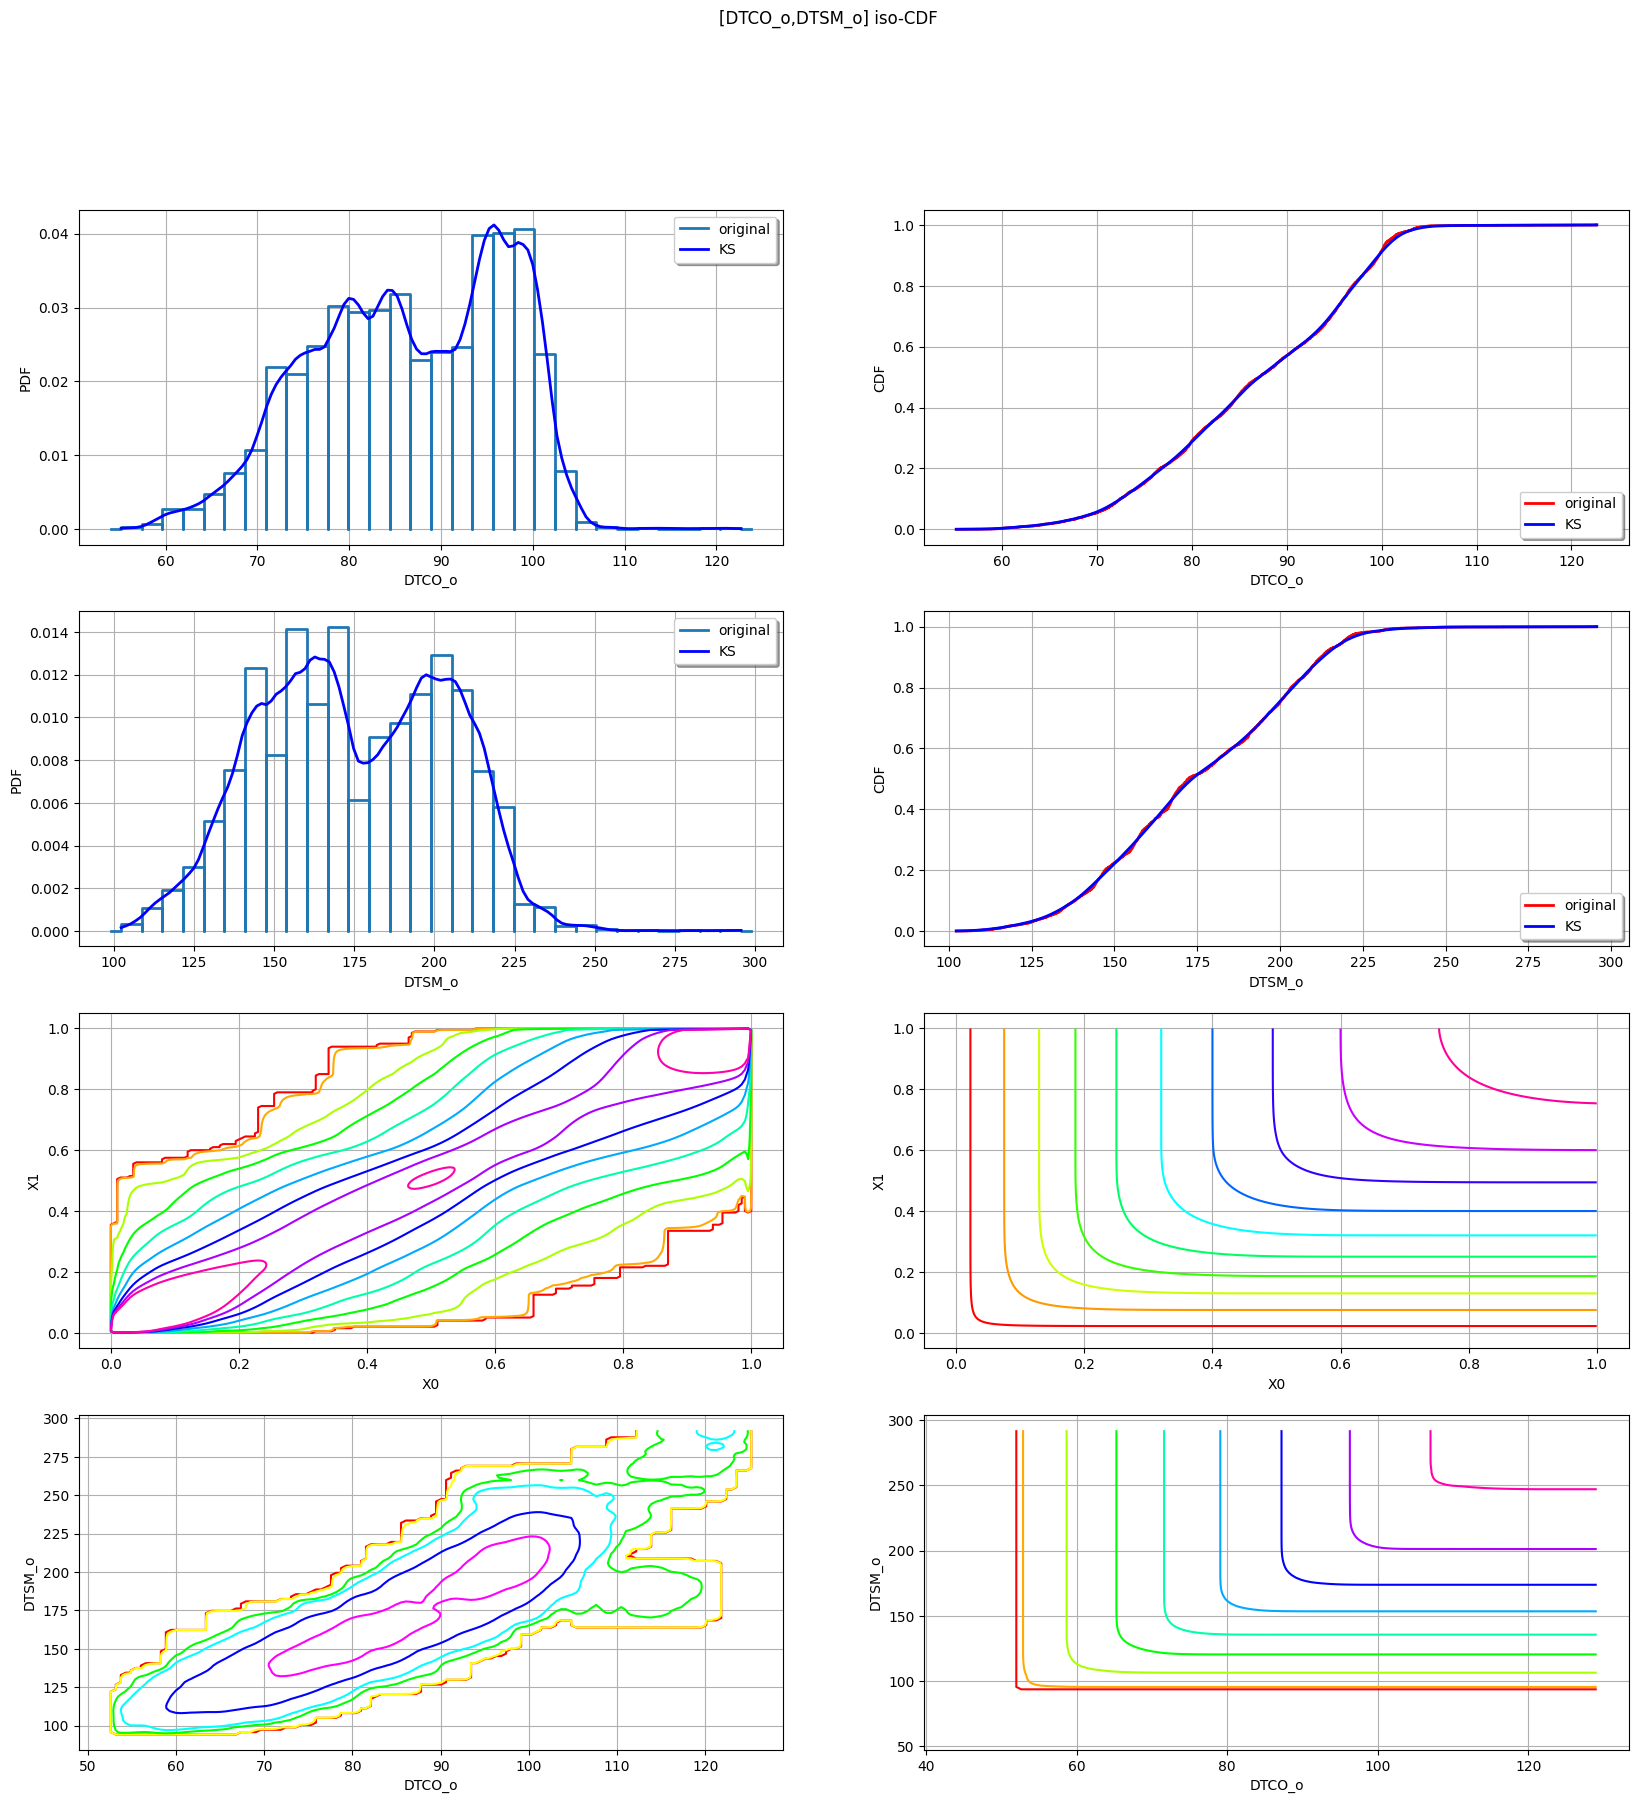

In [29]:
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(4, 2, 1)
_ = otv.View(graph1, figure=fig, axes=[ax])
ax = fig.add_subplot(4, 2, 2)
_ = otv.View(graph, figure=fig, axes=[ax])
ax = fig.add_subplot(4, 2, 3)
_ = otv.View(graph2, figure=fig, axes=[ax])
ax = fig.add_subplot(4, 2, 4)
_ = otv.View(graph3, figure=fig, axes=[ax])
ax = fig.add_subplot(4, 2, 5)
_ = otv.View(KernelSmoothing_copula_distribution.drawPDF(minPoint, maxPoint, pointNumber), figure=fig, axes=[ax] ,add_legend=False)
ax = fig.add_subplot(4, 2, 6)
_ = otv.View(KernelSmoothing_copula_distribution.drawCDF(minPoint, maxPoint, pointNumber), figure=fig, axes=[ax],add_legend=False)
ax = fig.add_subplot(4, 2, 7)
_ = otv.View(KernelSmoothing_bivariate_distribution.drawPDF(), figure=fig, axes=[ax] ,add_legend=False)
ax = fig.add_subplot(4, 2, 8)
_ = otv.View(KernelSmoothing_bivariate_distribution.drawCDF(), figure=fig, axes=[ax],add_legend=False)
_.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Non-parametric_Kernel_Smoothing_'+ filename +'_copula_modeling.png', dpi=200)

### Estimate a conditional quantile

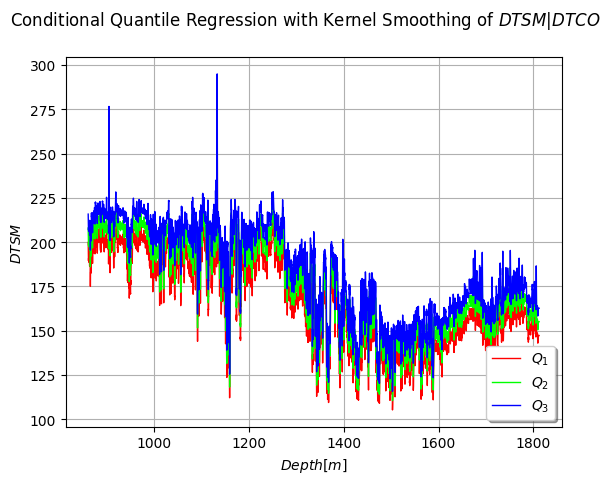

In [30]:
xobs = np.linspace(Depth_min, Depth_max, sample_size)
#sampleObs = ot.Sample([[xi] for xi in xobs])


x = [xi for xi in xobs]
yapp_Q1 = [KernelSmoothing_bivariate_distribution.computeConditionalQuantile(0.25, var1[i]) for i in range(sample_size)]
yapp_Q3 = [KernelSmoothing_bivariate_distribution.computeConditionalQuantile(0.75, var1[i]) for i in range(sample_size)]
yapp_Q2 = [KernelSmoothing_bivariate_distribution.computeConditionalQuantile(0.5, var1[i]) for i in range(sample_size)]
#yex = [distX.computeConditionalQuantile(0.5, sampleObs[i]) for i in range(N)]


cxy_app_Q1 = ot.Curve(x,yapp_Q1)
cxy_app_Q2 = ot.Curve(x,yapp_Q2)
cxy_app_Q3 = ot.Curve(x,yapp_Q3)
#cxy_ex = ot.Curve(x,yex)
graph_ = ot.Graph('Conditional Quantile Regression with Kernel Smoothing of $DTSM | DTCO$', '$Depth [m]$', '$DTSM$', True, '')
graph_.add(cxy_app_Q1)
graph_.add(cxy_app_Q2)
graph_.add(cxy_app_Q3)
#graph.add(cxy_ex)
graph_.setLegends(["$Q_1$", "$Q_2$", "$Q_3$"])
graph_.setLegendPosition('bottomright')
graph_.setColors(["red", "green", "blue"])
view = otv.View(graph_)
plt.show()
view.save(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Conditional Quantile Regression_'+ filename +'_with Kernel Smoothing.png', dpi=200)

### Summary of Median Statistics: Median Regression (Parametric Copula)

In [31]:
Point_yapp_Q1=ot.Point(yapp_Q1)
Point_yapp_Q2=ot.Point(yapp_Q2)
Point_yapp_Q3=ot.Point(yapp_Q3)

Sample_yapp=ot.Sample([Point_yapp_Q1, Point_yapp_Q2, Point_yapp_Q3])

array_yapp = np.array(Sample_yapp)

#sample_yapp = ot.Sample(array_yapp)
sample_yapp_Q1 = ot.Sample([[ui] for ui in array_yapp[0,:]])
sample_yapp_Q2 = ot.Sample([[ui] for ui in array_yapp[1,:]])
sample_yapp_Q3 = ot.Sample([[ui] for ui in array_yapp[2,:]])

error_yapp_Q2=var2-sample_yapp_Q2
error_yapp_IQR=sample_yapp_Q3-sample_yapp_Q1

print('Size=',error_yapp_Q2.getSize())
print('Name=',error_yapp_Q2.getDescription())
print('Minimum=',error_yapp_Q2.getMin())
print('1st quartile=',error_yapp_Q2.computeQuantilePerComponent(0.25))
print('Mean=',error_yapp_Q2.computeMean())
print('Median=',error_yapp_Q2.computeMedian())
print('3rd quartile=',error_yapp_Q2.computeQuantilePerComponent(0.75))
print('Maximum=',error_yapp_Q2.getMax())
print('Range=',error_yapp_Q2.computeRange())
print('Variance=',error_yapp_Q2.computeVariance())
print('Standard Deviation=',error_yapp_Q2.computeStandardDeviation())
print('Skewness=',error_yapp_Q2.computeSkewness())
print('Kurtosis=',error_yapp_Q2.computeKurtosis())

Size= 6244
Name= [DTSM_o]
Minimum= [-66.3831]
1st quartile= [-3.16984]
Mean= [0.00274751]
Median= [-0.261698]
3rd quartile= [2.89247]
Maximum= [45.3685]
Range= [111.752]
Variance= [39.3533]
Standard Deviation= [6.27322]
Skewness= [0.362721]
Kurtosis= [10.3309]


### Scatterplot Median Regression Kernel Smoothing Copula

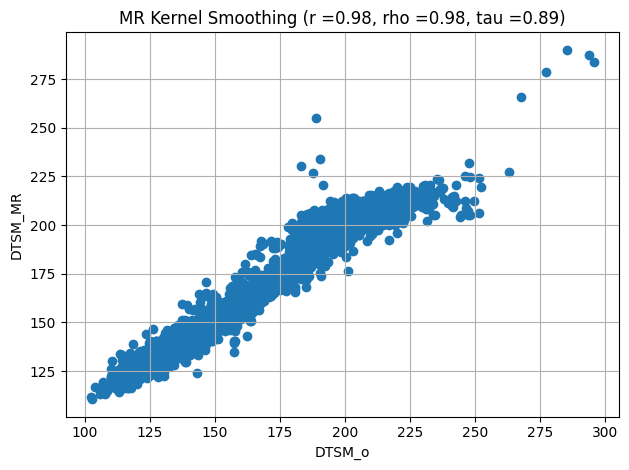

<Figure size 640x480 with 0 Axes>

In [35]:
Sample_yapp_Q1=ot.Sample([Point_yapp_Q1])
array_yapp_Q1 = np.array(Sample_yapp_Q1)
Sample_yapp_Q2=ot.Sample([Point_yapp_Q2])
array_yapp_Q2 = np.array(Sample_yapp_Q2)
Sample_yapp_Q3=ot.Sample([Point_yapp_Q3])
array_yapp_Q3 = np.array(Sample_yapp_Q3)
array_var2 = np.array(var2)
x=array_var2[:,0]
y=array_yapp_Q2[0,:]
xmin=np.min(x)
xmax=np.max(x)
ymin=np.min(y)
ymax=np.max(y)
xlab='DTSM_o'
ylab='DTSM_MR'
pearson = np.corrcoef(x, y)[0,1]
spearman, p = scipy.stats.spearmanr(x, y)
kendall, p = scipy.stats.kendalltau(x, y)
#spearman = kendall
title='MR Kernel Smoothing (r ='+ "{:4.2f}".format(pearson) +', rho ='+ "{:4.2f}".format(spearman) +', tau ='+ "{:4.2f}".format(kendall) +')'

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(title)
ax.grid(True)
fig.tight_layout()
plt.show()
plt.savefig(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Scatterplot Median Regression_'+ filename +'_Kernel Smoothing Copula.png', dpi=200)

### Median Regression Parametric Copula

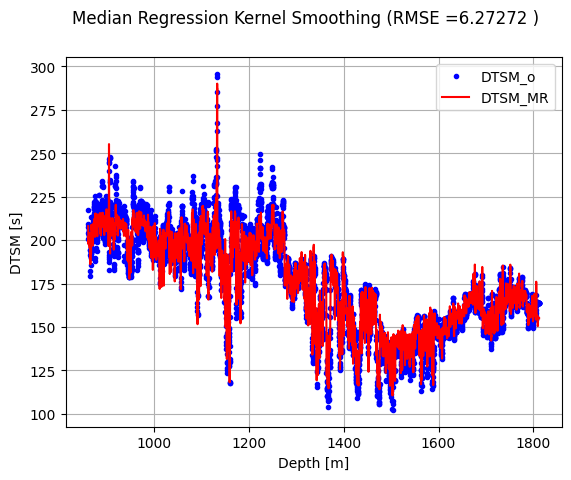

In [33]:
rmse_=rmse(array_var2[:,0],array_yapp_Q2[0,:])

fig4, ax = plt.subplots()
fig4.suptitle('Median Regression Kernel Smoothing (RMSE ='+ "{:3n}".format(rmse_) +' )')

plt.xlabel("Depth [m]")
plt.ylabel("DTSM [s]")

ax.plot(xobs, array_var2[:,0], 'b.',  label='DTSM_o')

ax.plot(xobs, array_yapp_Q2[0,:], 'r-', label='DTSM_MR')

ax.grid(True)

ax.legend(loc='best')

plt.show()
plt.savefig(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/Median Regression_'+ filename +'_Kernel Smoothing Copula.png', dpi=200)

multipage(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Figures/'+ filename +'_MR Kernel Smoothing Copula.pdf')

plt.close('all')

### Export Median Regression Kernel Smoothing Copula modeling to csv format

In [36]:
df=pd.DataFrame()
df['DEPTH'] = xobs.tolist()
df['DTSM_o'] = array_var2[:,0].tolist()
df['DTSM_MR'] = array_yapp_Q2[0,:].tolist()
df['DTSM_Q1'] = array_yapp_Q1[0,:].tolist()
df['DTSM_Q3'] = array_yapp_Q3[0,:].tolist()
df.to_csv(dir + '/drive/MyDrive/Notebooks/Python3/Copula_Median_Regression/Output/'+ filename +'_MR Kernel Smoothing Copula.csv')